
<div style="padding:26px 30px; border-radius:16px; background:linear-gradient(135deg,#0f766e,#115e59); color:white;">
  <h1 style="margin:0; font-size:34px;">Regresión lineal múltiple</h1>
  <p style="margin:10px 0 0; font-size:18px;">Machine Learning · Notebook de clase</p>
</div>

<br>

Este notebook reproduce de forma ordenada el procedimiento trabajado en las **diapositivas y apuntes de clase**: carga de datos, codificación de la variable categórica, separación entrenamiento/prueba, ajuste de la regresión múltiple y selección de variables mediante **OLS**.

Las gráficas incluidas utilizan únicamente las variables y resultados que ya forman parte del ejercicio.


## 1. Concepto

La **regresión múltiple** permite predecir una variable dependiente a partir de **dos o más variables independientes** mediante una relación lineal.

Su forma general es:

$$
y = b_0 + b_1x_1 + b_2x_2 + \cdots + b_nx_n
$$

donde:

- $y$: variable dependiente.
- $b_0$: constante o intercepto.
- $b_1, \ldots, b_n$: coeficientes.
- $x_1, \ldots, x_n$: variables independientes.

## 2. Importación de librerías

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3. Importación del conjunto de datos

In [27]:
dataset = pd.read_csv('https://cdtiueb.com.co/doctorado/Empresas.csv')

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

dataset

,Gasto_IyD,Gasto_Administracion,Gasto_Marketing,Ciudad,Ganancia
0,165349.20,136897.80,471784.10,Bogota,192261.83
1,162597.70,151377.59,443898.53,Cali,191792.06
2,153441.51,101145.55,407934.54,Barranquilla,191050.39
3,144372.41,118671.85,383199.62,Bogota,182901.99
4,142107.34,91391.77,366168.42,Barranquilla,166187.94
5,131876.90,99814.71,362861.36,Bogota,156991.12
6,134615.46,147198.87,127716.82,Cali,156122.51
7,130298.13,145530.06,323876.68,Barranquilla,155752.60
8,120542.52,148718.95,311613.29,Bogota,152211.77
9,123334.88,108679.17,304981.62,Cali,149759.96



El conjunto de datos contiene las variables trabajadas en clase:

- **Gasto_IyD**
- **Gasto_Administracion**
- **Gasto_Marketing**
- **Ciudad**
- **Ganancia**

La variable objetivo es **Ganancia**.


### Contenido de la variable X

In [28]:
print("=" * 60)
print("Datos en X")
print("=" * 60)
print(X)

Datos en X
[[165349.2 136897.8 471784.1 'Bogota']
 [162597.7 151377.59 443898.53 'Cali']
 [153441.51 101145.55 407934.54 'Barranquilla']
 [144372.41 118671.85 383199.62 'Bogota']
 [142107.34 91391.77 366168.42 'Barranquilla']
 [131876.9 99814.71 362861.36 'Bogota']
 [134615.46 147198.87 127716.82 'Cali']
 [130298.13 145530.06 323876.68 'Barranquilla']
 [120542.52 148718.95 311613.29 'Bogota']
 [123334.88 108679.17 304981.62 'Cali']
 [101913.08 110594.11 229160.95 'Barranquilla']
 [100671.96 91790.61 249744.55 'Cali']
 [93863.75 127320.38 249839.44 'Barranquilla']
 [91992.39 135495.07 252664.93 'Cali']
 [119943.24 156547.42 256512.92 'Barranquilla']
 [114523.61 122616.84 261776.23 'Bogota']
 [78013.11 121597.55 264346.06 'Cali']
 [94657.16 145077.58 282574.31 'Bogota']
 [91749.16 114175.79 294919.57 'Barranquilla']
 [86419.7 153514.11 0.0 'Bogota']
 [76253.86 113867.3 298664.47 'Cali']
 [78389.47 153773.43 299737.29 'Bogota']
 [73994.56 122782.75 303319.26 'Barranquilla']
 [67532.53 105

### Contenido de la variable y

In [29]:
print("=" * 60)
print("Datos en y")
print("=" * 60)
print(y)

Datos en y
[192261.83 191792.06 191050.39 182901.99 166187.94 156991.12 156122.51
 155752.6  152211.77 149759.96 146121.95 144259.4  141585.52 134307.35
 132602.65 129917.04 126992.93 125370.37 124266.9  122776.86 118474.03
 111313.02 110352.25 108733.99 108552.04 107404.34 105733.54 105008.31
 103282.38 101004.64  99937.59  97483.56  97427.84  96778.92  96712.8
  96479.51  90708.19  89949.14  81229.06  81005.76  78239.91  77798.83
  71498.49  69758.98  65200.33  64926.08  49490.75  42559.73  35673.41
  14681.4 ]



## 4. Exploración gráfica de las variables numéricas

Se observa gráficamente la relación entre cada gasto y la **Ganancia**, sin modificar el procedimiento del modelo.


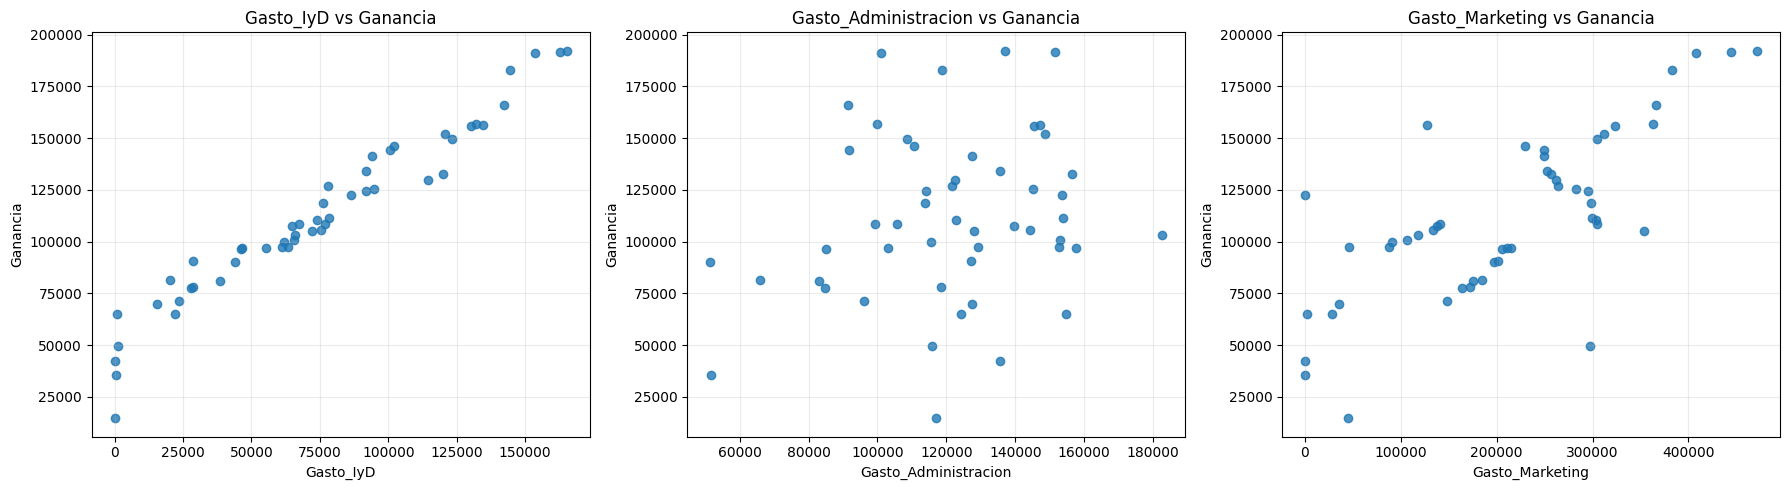

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variables = ['Gasto_IyD', 'Gasto_Administracion', 'Gasto_Marketing']

for ax, variable in zip(axes, variables):
    ax.scatter(dataset[variable], dataset['Ganancia'], alpha=0.8)
    ax.set_title(f'{variable} vs Ganancia')
    ax.set_xlabel(variable)
    ax.set_ylabel('Ganancia')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 5. Conversión de la variable categórica a variables dummy

La variable **Ciudad** es categórica. Por esta razón se utiliza `pd.get_dummies()` para transformarla en variables numéricas de 0 y 1, tal como se realizó en clase.

Se utiliza `drop_first=True` para dejar una ciudad como categoría de referencia.


In [31]:
# Aplicar get_dummies
df_limpio = pd.DataFrame(
    X,
    columns=['Gasto_IyD', 'Gasto_Administracion', 'Gasto_Marqueting', 'Ciudad']
)

df_codificado = pd.get_dummies(
    df_limpio,
    columns=['Ciudad'],
    drop_first=True
)

# Convertir columnas booleanas a int (1 y 0)
for col in df_codificado.columns:
    if df_codificado[col].dtype == 'bool':
        df_codificado[col] = df_codificado[col].astype(int)

print("--- DATOS CODIFICADOS (SIN REORDENAR) ---")
print("\n")
df_codificado

--- DATOS CODIFICADOS (SIN REORDENAR) ---




,Gasto_IyD,Gasto_Administracion,Gasto_Marqueting,Ciudad_Bogota,Ciudad_Cali
0,165349.2,136897.8,471784.1,1,0
1,162597.7,151377.59,443898.53,0,1
2,153441.51,101145.55,407934.54,0,0
3,144372.41,118671.85,383199.62,1,0
4,142107.34,91391.77,366168.42,0,0
5,131876.9,99814.71,362861.36,1,0
6,134615.46,147198.87,127716.82,0,1
7,130298.13,145530.06,323876.68,0,0
8,120542.52,148718.95,311613.29,1,0
9,123334.88,108679.17,304981.62,0,1


### Orden de las variables codificadas

In [32]:
# Identificar columnas dummy de Ciudad
columnas_Ciudad = [
    col for col in df_codificado.columns
    if col.startswith('Ciudad_')
]

# Identificar columnas numéricas
columnas_numericas = [
    'Gasto_IyD',
    'Gasto_Administracion',
    'Gasto_Marqueting'
]

# Primero las variables dummy de Ciudad y luego las variables numéricas
nuevo_orden = columnas_Ciudad + columnas_numericas

# Reordenar el DataFrame
df_codificado = df_codificado[nuevo_orden]

print("--- DATOS CODIFICADOS ---")
X = df_codificado
X

--- DATOS CODIFICADOS ---


,Ciudad_Bogota,Ciudad_Cali,Gasto_IyD,Gasto_Administracion,Gasto_Marqueting
0,1,0,165349.2,136897.8,471784.1
1,0,1,162597.7,151377.59,443898.53
2,0,0,153441.51,101145.55,407934.54
3,1,0,144372.41,118671.85,383199.62
4,0,0,142107.34,91391.77,366168.42
5,1,0,131876.9,99814.71,362861.36
6,0,1,134615.46,147198.87,127716.82
7,0,0,130298.13,145530.06,323876.68
8,1,0,120542.52,148718.95,311613.29
9,0,1,123334.88,108679.17,304981.62



## 6. Separación del conjunto de entrenamiento y prueba

Se utiliza la misma división de clase:

- **80 %** para entrenamiento.
- **20 %** para prueba.
- `random_state = 0`.


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

### Datos de entrenamiento

In [34]:
X_train.head()

,Ciudad_Bogota,Ciudad_Cali,Gasto_IyD,Gasto_Administracion,Gasto_Marqueting
33,0,0,55493.95,103057.49,214634.81
35,1,0,46014.02,85047.44,205517.64
26,0,0,75328.87,144135.98,134050.07
34,0,1,46426.07,157693.92,210797.67
18,0,0,91749.16,114175.79,294919.57


In [35]:
y_train

array([ 96778.92,  96479.51, 105733.54,  96712.8 , 124266.9 , 155752.6 ,
       132602.65,  64926.08,  35673.41, 101004.64, 129917.04,  99937.59,
        97427.84, 126992.93,  71498.49, 118474.03,  69758.98, 152211.77,
       134307.35, 107404.34, 156991.12, 125370.37,  78239.91,  14681.4 ,
       191792.06, 141585.52,  89949.14, 108552.04, 156122.51, 108733.99,
        90708.19, 111313.02, 122776.86, 149759.96,  81005.76,  49490.75,
       182901.99, 192261.83,  42559.73,  65200.33])

## 7. Ajuste del modelo de regresión lineal múltiple

In [36]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## 8. Predicción sobre el conjunto de prueba

In [37]:
y_pred = regressor.predict(X_test)

### Comparación entre los valores reales y los valores predichos

In [38]:
for i in range(len(y_test)):
    print(
        y_test[i],
        '----------->',
        round(y_pred[i], 2),
        'Diferencia',
        round((y_test[i] - y_pred[i]), 2),
        '--- Porcentaje-----',
        round(((1 - (y_test[i] / y_pred[i])) * 100), 2),
        '%'
    )

103282.38 -----------> 103015.2 Diferencia 267.18 --- Porcentaje----- -0.26 %
144259.4 -----------> 132582.28 Diferencia 11677.12 --- Porcentaje----- -8.81 %
146121.95 -----------> 132447.74 Diferencia 13674.21 --- Porcentaje----- -10.32 %
77798.83 -----------> 71976.1 Diferencia 5822.73 --- Porcentaje----- -8.09 %
191050.39 -----------> 178537.48 Diferencia 12512.91 --- Porcentaje----- -7.01 %
105008.31 -----------> 116161.24 Diferencia -11152.93 --- Porcentaje----- 9.6 %
81229.06 -----------> 67851.69 Diferencia 13377.37 --- Porcentaje----- -19.72 %
97483.56 -----------> 98791.73 Diferencia -1308.17 --- Porcentaje----- 1.32 %
110352.25 -----------> 113969.44 Diferencia -3617.19 --- Porcentaje----- 3.17 %
166187.94 -----------> 167921.07 Diferencia -1733.13 --- Porcentaje----- 1.03 %



### Gráfica: valores reales vs. valores predichos

Los puntos más cercanos a la diagonal representan predicciones más próximas a los valores reales.


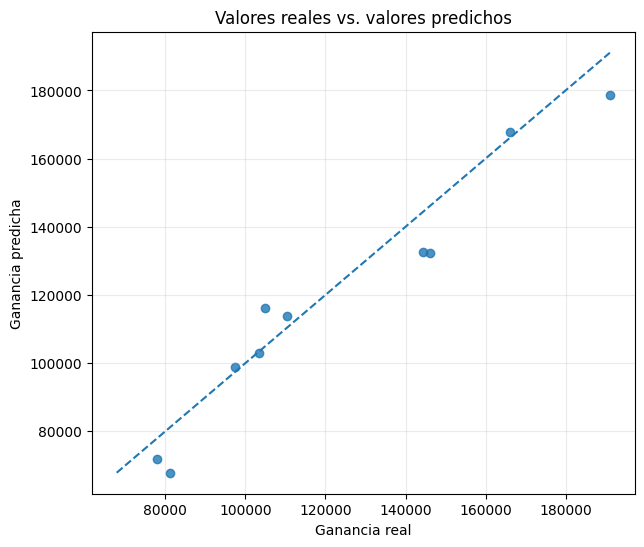

In [39]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.8)

limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--'
)

plt.xlabel('Ganancia real')
plt.ylabel('Ganancia predicha')
plt.title('Valores reales vs. valores predichos')
plt.grid(alpha=0.25)
plt.show()


## 9. Selección de variables con OLS

En los apuntes de clase se utiliza `statsmodels` para evaluar la significancia de las variables.

Primero se incorpora una columna de unos para representar el **intercepto** y se trabaja con un nivel de significancia:

\[
SL=0.05
\]

La selección se realiza eliminando progresivamente la variable con el valor \(P>|t|\) más alto cuando supera 0.05.


In [40]:
import statsmodels.api as sm

X = np.append(
    arr=np.ones((50, 1)).astype(int),
    values=X,
    axis=1
)

# Nivel de significancia
SL = 0.05

X

array([[1, 1, 0, 165349.2, 136897.8, 471784.1],
       [1, 0, 1, 162597.7, 151377.59, 443898.53],
       [1, 0, 0, 153441.51, 101145.55, 407934.54],
       [1, 1, 0, 144372.41, 118671.85, 383199.62],
       [1, 0, 0, 142107.34, 91391.77, 366168.42],
       [1, 1, 0, 131876.9, 99814.71, 362861.36],
       [1, 0, 1, 134615.46, 147198.87, 127716.82],
       [1, 0, 0, 130298.13, 145530.06, 323876.68],
       [1, 1, 0, 120542.52, 148718.95, 311613.29],
       [1, 0, 1, 123334.88, 108679.17, 304981.62],
       [1, 0, 0, 101913.08, 110594.11, 229160.95],
       [1, 0, 1, 100671.96, 91790.61, 249744.55],
       [1, 0, 0, 93863.75, 127320.38, 249839.44],
       [1, 0, 1, 91992.39, 135495.07, 252664.93],
       [1, 0, 0, 119943.24, 156547.42, 256512.92],
       [1, 1, 0, 114523.61, 122616.84, 261776.23],
       [1, 0, 1, 78013.11, 121597.55, 264346.06],
       [1, 1, 0, 94657.16, 145077.58, 282574.31],
       [1, 0, 0, 91749.16, 114175.79, 294919.57],
       [1, 1, 0, 86419.7, 153514.11, 0.0],
 


### Modelo con todas las variables

El orden de las columnas es:

1. Constante
2. Ciudad_Bogota
3. Ciudad_Cali
4. Gasto_IyD
5. Gasto_Administracion
6. Gasto_Marqueting


In [41]:
# Convertir X_opt a array de NumPy
X_opt = np.array(X[:, [0, 1, 2, 3, 4, 5]])

# Asegurar que los datos sean tipo float
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     169.9
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.34e-27
Time:                        20:16:44   Log-Likelihood:                -525.38
No. Observations:                  50   AIC:                             1063.
Df Residuals:                      44   BIC:                             1074.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.032e+04   7251.767      6.940      0.000    3.57e+04    6.49e+04
x1          -240.6758   3338.857     -0.072      0.943   -6969.701    6488.349
x2          -198.7888   3371.007     -0.059      0.953   -6992.607    6595.030
x3             0.8060      0.046     17.369      0.000       0.712       0.900
x4            -0.0270      0.052     -0.517      0.608      -0.132       0.078
x5             0.0270      0.017      1.574      0.123      -0.008       0.062
==============================================================================
Omnibus:                       14.782   Durbin-Watson:                   1.283
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.266
Skew:                          -0.948   Prob(JB):                     2.41e-05
Kurtosis:                       5.572   Cond. No.                     1.56e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.56e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


El mayor valor \(P>|t|\) corresponde a **Ciudad_Cali**, por lo que se elimina esa variable.


In [42]:
X_opt = np.array(X[:, [0, 1, 3, 4, 5]])
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     217.2
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           8.50e-29
Time:                        20:16:44   Log-Likelihood:                -525.38
No. Observations:                  50   AIC:                             1061.
Df Residuals:                      45   BIC:                             1070.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.018e+04   6747.623      7.437      0.000    3.66e+04    6.38e+04
x1          -136.5042   2801.719     -0.049      0.961   -5779.456    5506.447
x2             0.8059      0.046     17.571      0.000       0.714       0.898
x3            -0.0269      0.052     -0.521      0.605      -0.131       0.077
x4             0.0271      0.017      1.625      0.111      -0.007       0.061
==============================================================================
Omnibus:                       14.892   Durbin-Watson:                   1.284
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.665
Skew:                          -0.949   Prob(JB):                     1.97e-05
Kurtosis:                       5.608   Cond. No.                     1.43e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.43e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


Ahora el mayor valor \(P>|t|\) corresponde a **Ciudad_Bogota**, por lo que se elimina.


In [43]:
X_opt = np.array(X[:, [0, 3, 4, 5]])
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     296.0
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           4.53e-30
Time:                        20:16:44   Log-Likelihood:                -525.39
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      46   BIC:                             1066.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.012e+04   6572.353      7.626      0.000    3.69e+04    6.34e+04
x1             0.8057      0.045     17.846      0.000       0.715       0.897
x2            -0.0268      0.051     -0.526      0.602      -0.130       0.076
x3             0.0272      0.016      1.655      0.105      -0.006       0.060
==============================================================================
Omnibus:                       14.838   Durbin-Watson:                   1.282
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.442
Skew:                          -0.949   Prob(JB):                     2.21e-05
Kurtosis:                       5.586   Cond. No.                     1.40e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


El siguiente valor \(P>|t|\) más alto corresponde a **Gasto_Administracion**, por lo que se elimina.


In [44]:
X_opt = np.array(X[:, [0, 3, 5]])
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     450.8
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           2.16e-31
Time:                        20:16:44   Log-Likelihood:                -525.54
No. Observations:                  50   AIC:                             1057.
Df Residuals:                      47   BIC:                             1063.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.698e+04   2689.933     17.464      0.000    4.16e+04    5.24e+04
x1             0.7966      0.041     19.266      0.000       0.713       0.880
x2             0.0299      0.016      1.927      0.060      -0.001       0.061
==============================================================================
Omnibus:                       14.677   Durbin-Watson:                   1.257
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               21.161
Skew:                          -0.939   Prob(JB):                     2.54e-05
Kurtosis:                       5.575   Cond. No.                     5.32e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.32e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


En este paso **Gasto_Marqueting** presenta un valor \(P>|t|\) superior a 0.05, por lo que se elimina.


In [45]:
X_opt = np.array(X[:, [0, 3]])
X_opt = X_opt.astype(float)

regression_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regression_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           3.50e-32
Time:                        20:16:44   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.903e+04   2537.897     19.320      0.000    4.39e+04    5.41e+04
x1             0.8543      0.029     29.151      0.000       0.795       0.913
==============================================================================
Omnibus:                       13.727   Durbin-Watson:                   1.116
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.536
Skew:                          -0.911   Prob(JB):                     9.44e-05
Kurtosis:                       5.361   Cond. No.                     1.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Gráfica del modelo final: Gasto_IyD vs Ganancia

Esta es la más importante porque permite ver directamente la recta obtenida por el modelo final.

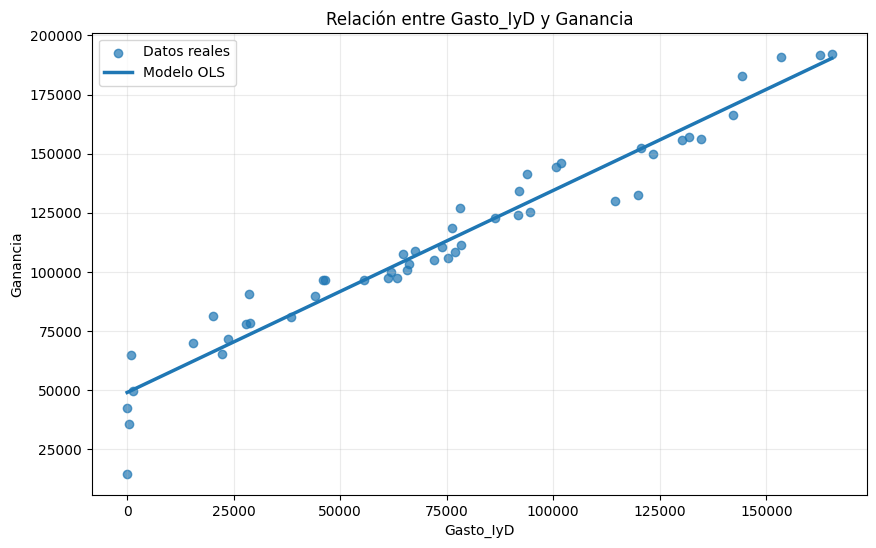

In [46]:
# Valores de Gasto_IyD
gasto_iyd = X[:, 3].astype(float)

# Predicciones del modelo final
y_pred_OLS = regression_OLS.predict(X_opt)

# Ordenar los valores para dibujar correctamente la recta
orden = np.argsort(gasto_iyd)

plt.figure(figsize=(10, 6))

plt.scatter(
    gasto_iyd,
    y,
    alpha=0.7,
    label='Datos reales'
)

plt.plot(
    gasto_iyd[orden],
    y_pred_OLS[orden],
    linewidth=2.5,
    label='Modelo OLS'
)

plt.title('Relación entre Gasto_IyD y Ganancia')
plt.xlabel('Gasto_IyD')
plt.ylabel('Ganancia')
plt.legend()
plt.grid(alpha=0.25)

plt.show()

### Representación gráfica del modelo final

La siguiente gráfica muestra la relación entre **Gasto_IyD** y **Ganancia**. Los puntos representan los valores observados y la línea corresponde a las predicciones obtenidas con el modelo OLS final.

## Valores reales vs. valores predichos

Esta gráfica sirve para observar qué tan cerca están las predicciones del modelo de los valores reales.

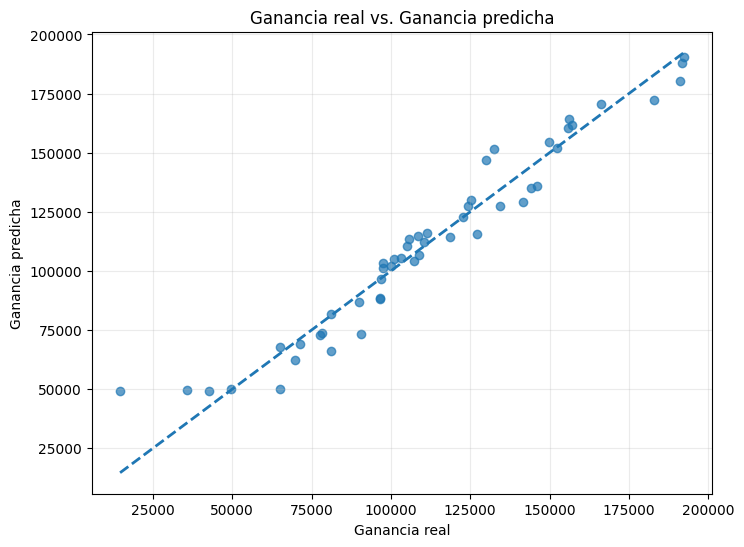

In [48]:
# Predicciones del modelo final
y_pred_OLS = regression_OLS.predict(X_opt)

plt.figure(figsize=(8, 6))

plt.scatter(
    y,
    y_pred_OLS,
    alpha=0.7
)

# Línea de referencia: predicción perfecta
limite_min = min(y.min(), y_pred_OLS.min())
limite_max = max(y.max(), y_pred_OLS.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle='--',
    linewidth=2
)

plt.title('Ganancia real vs. Ganancia predicha')
plt.xlabel('Ganancia real')
plt.ylabel('Ganancia predicha')
plt.grid(alpha=0.25)

plt.show()

### Valores reales y valores predichos

La gráfica compara la **Ganancia real** con la **Ganancia estimada por el modelo**. Cuanto más cerca se encuentren los puntos de la línea diagonal, más próximas son las predicciones a los valores observados.

## Gráfica de residuos del modelo

Esta también sale directamente del modelo OLS. El residuo es simplemente:

$$Residuo=y− \widehat{y}$$


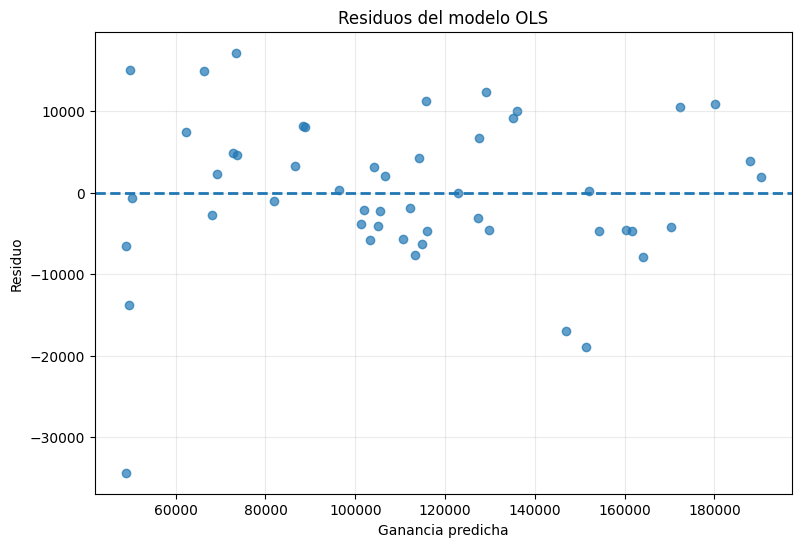

In [49]:
# Calcular residuos
residuos = y - y_pred_OLS

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred_OLS,
    residuos,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.title('Residuos del modelo OLS')
plt.xlabel('Ganancia predicha')
plt.ylabel('Residuo')
plt.grid(alpha=0.25)

plt.show()

### Residuos del modelo

Los residuos representan la diferencia entre la **Ganancia observada** y la **Ganancia predicha** por el modelo.

La línea horizontal en cero permite identificar visualmente si las predicciones se encuentran por encima o por debajo de los valores reales.


## 10. Modelo obtenido

Después del procedimiento de selección utilizado en clase, el modelo final conserva **Gasto_IyD**:

$$
\boxed{y=49030+0.8543\times Gasto\_IyD}
$$

En este modelo:

- **49 030** corresponde al intercepto aproximado.
- **0.8543** es el coeficiente asociado a `Gasto_IyD`.


### Ejemplo trabajado en clase

In [47]:
model_y = 49030 + 0.8543 * 72107.6
model_y

110631.52268


Para un valor de `Gasto_IyD = 72107.6`, el modelo final calcula la ganancia utilizando directamente la ecuación obtenida en clase.
